<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">BootCamp Nova Geração — Arquiteturas de Agentes com LangGraph + LiteLLM</h1>

Este notebook transforma as cinco arquiteturas do bootcamp em implementações com Python, em um cenário fictício de **operações logísticas**. A proposta é enxergar, na prática, como a arquitetura altera o fluxo de decisão, as tools disponíveis, o estado e os mecanismos de controle do agente.

As arquiteturas implementadas são:

1. **ReAct** — decidir → usar tool → observar → decidir novamente;
2. **Planejamento** — planner → executor → replanner → síntese;
3. **Memória** — continuidade por estado persistido;
4. **Multiagente** — orquestrador + especialistas + consolidação;
5. **Reflexão** — gerar → criticar por rubrica → revisar.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">👩‍💻 Não conhece Python? Este notebook também foi feito para você</h2>

**Você não precisa saber programar para acompanhar o exercício.** O código foi propositalmente escrito como um roteiro comentado. Antes das instruções importantes existe uma linha iniciada por `#` explicando, em linguagem simples, **o que aquela próxima linha executa e qual papel ela cumpre na arquitetura**.

Ao avançar pelas células, use esta sequência de leitura:

1. **Leia primeiro os comentários iniciados por `#`.** Eles funcionam como a narração do passo a passo.
2. **Observe a linha de código logo abaixo do comentário.** Não é necessário memorizar a sintaxe; procure apenas associar a explicação à execução.
3. **Nos trechos de LangGraph, procure os conceitos arquiteturais:** estado, nó, aresta, tool, roteamento, memória e critérios de parada.
4. **Execute as células na ordem**, de cima para baixo. As células posteriores reutilizam variáveis e funções criadas anteriormente.
5. **Nas células de interação, escreva seu próprio prompt** quando aparecer `input(...)` e observe como cada arquitetura responde à mesma missão de maneira diferente.

> **Dica para iniciantes:** quando aparecer uma função (`def ...`), pense nela como uma pequena “máquina” que recebe uma entrada, executa uma responsabilidade específica e devolve uma saída. Quando aparecer um nó do LangGraph, pense nele como uma etapa dessa máquina maior.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">Cenário didático</h2>

Você opera uma **central de controle logístico de entregas**. O problema exige combinar múltiplas skills e fontes: SLA de entregas, capacidade dos hubs, incidentes, desempenho de transportadoras, atendimento e políticas operacionais.

O objetivo não é resolver um case empresarial específico. O cenário existe para dar uma perspectiva prática sobre como soluções agentic são construídas com código e como arquiteturas diferentes se comportam diante de diferentes solicitações do usuário.

> **Nota sobre ReAct:** o notebook mostra chamadas de tools, observações e transições de estado. Ele não imprime o chain-of-thought privado do modelo.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">0. Instalação</h2>

Execute **uma única vez**. Todos os requirements do notebook ficam nesta célula.

> Se você não programa: nesta célula, basta entender que estamos preparando o ambiente com as bibliotecas necessárias. Leia os comentários e execute o bloco inteiro; você não precisa dominar cada nome de pacote neste momento.

In [1]:
# Esta célula instala todas as bibliotecas usadas no restante do notebook.
# O comando especial "%pip" executa o instalador de pacotes Python dentro do próprio Jupyter/Colab.
# A opção "-qU" significa: instalar de forma mais silenciosa (quiet) e atualizar versões quando necessário (upgrade).
# Você precisa executar esta célula apenas uma vez por ambiente/kernel.
# A lib "requests" é incluída para garantir que as chamadas HTTP à API Sandbox funcionem corretamente.
%pip install -q \
    "pyOpenSSL==26.2.0" \
    "cryptography>=46.0.5,<49.0.0" \
    "langgraph>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-litellm>=0.7,<0.8" \
    "litellm>=1.70" \
    "pydantic>=2.7,<3.0" \
    "typing-extensions>=4.12"

Note: you may need to restart the kernel to use updated packages.


<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">1. Configuração do modelo</h2>

O notebook usa **LiteLLM via `ChatLiteLLM`**, configurado para enviar as chamadas HTTP (via `requests`) ao endpoint da **API Sandbox** em `https://chat.eloagents.click/api/v1/sandbox/chat/completions`.

Coloque sua chave em `API_KEY` e, se necessário, altere o `MODEL` para outro modelo disponível na Sandbox.

> **Para quem não conhece Python:** esta é uma das células mais importantes para acompanhar pelos comentários. Ela prepara os objetos que serão reutilizados posteriormente e introduz conceitos como `LLM`, mensagens, `StateGraph`, `ToolNode` e memória.


In [ ]:
# Importa recursos do próprio Python para trabalhar com variáveis de ambiente, como a chave da API.
import os

# Importa suporte a JSON, formato usado para trocar dados estruturados entre agentes e tools.
import json

# Importa operadores auxiliares; mais adiante usaremos "operator.add" para juntar relatórios de agentes paralelos.
import operator

# Path facilita trabalhar com caminhos de arquivos e pastas sem depender do sistema operacional.
from pathlib import Path

# Literal permite declarar que uma variável só pode assumir alguns textos específicos, como "continue" ou "finish".
from typing import Literal

# TypedDict descreve a estrutura do estado que circula pelo LangGraph; Annotated adiciona regras especiais a alguns campos.
from typing_extensions import TypedDict, Annotated

# NumPy oferece operações numéricas; neste notebook ele também ajuda a criar dados sintéticos e percentis.
import numpy as np

# Pandas é a biblioteca usada para ler, agrupar, filtrar e resumir os arquivos CSV do exercício.
import pandas as pd

# BaseModel e Field, do Pydantic, permitem exigir respostas estruturadas do LLM em algumas arquiteturas.
from pydantic import BaseModel, Field

# Estes recursos do IPython exibem imagens, Markdown e outros objetos de forma amigável dentro do notebook.
from IPython.display import Image, Markdown, display

# ChatLiteLLM é a ponte que permite chamar diferentes provedores de LLM por meio da interface LiteLLM.
from langchain_litellm import ChatLiteLLM

# Estas classes representam mensagens com papéis diferentes: usuário, sistema, tool e mensagem genérica.
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, BaseMessage

# O decorator @tool transforma uma função Python comum em uma ferramenta que o LLM pode solicitar.
from langchain_core.tools import tool

# StateGraph é o construtor principal do LangGraph; START e END marcam entrada e saída do fluxo.
from langgraph.graph import StateGraph, MessagesState, START, END

# add_messages é um "reducer": ele ensina o LangGraph a acumular mensagens no estado em vez de sobrescrevê-las.
from langgraph.graph.message import add_messages

# ToolNode é um nó pronto do LangGraph capaz de executar automaticamente uma tool pedida pelo modelo.
from langgraph.prebuilt import ToolNode

# InMemorySaver guarda o estado de uma conversa em memória durante a execução do notebook.
from langgraph.checkpoint.memory import InMemorySaver

# ============================================================================
# CONFIGURAÇÃO QUE O ALUNO PRECISA ALTERAR
# ============================================================================

# Substitua o texto abaixo pela sua própria chave de API antes de executar chamadas ao modelo.
API_KEY = ""

# Define qual modelo será chamado pela API Sandbox
# IMPORTANTE: O prefixo "openai/" força o LiteLLM a usar o provider OpenAI (HTTP/requests)
# em vez de tentar autenticar via Vertex AI / Google Cloud.
MODEL = "openai/gemini-3-flash-preview"

# URL base da API Sandbox (endpoint compatível com OpenAI Chat Completions).
API_BASE_URL = "https://chat.eloagents.click/api"

# Coloca a chave na variável de ambiente para que o LiteLLM a encontre automaticamente.
os.environ["OPENAI_API_KEY"] = API_KEY

# Configura o LiteLLM para usar a URL da API Sandbox como base URL customizada.
# Isso faz com que todas as chamadas sejam direcionadas para o endpoint correto via requests.
os.environ["OPENAI_API_BASE"] = API_BASE_URL

# Cria o objeto "llm", que será reutilizado por todas as arquiteturas do notebook.
# temperature=0.1 reduz a aleatoriedade, favorecendo respostas mais estáveis para o exercício.
# O parâmetro api_base garante que o ChatLiteLLM envie as requisições para a Sandbox API.
llm = ChatLiteLLM(model=MODEL, temperature=0.1, api_base=API_BASE_URL)

# Verifica se o aluno ainda não substituiu a chave de exemplo.
if API_KEY == "COLE_SUA_API_KEY_AQUI":
    # Exibe um aviso amigável: os grafos podem ser estudados, mas o LLM não responderá sem uma chave válida.
    print("⚠️ Grafo e código podem ser inspecionados, mas as chamadas ao LLM só funcionarão após preencher API_KEY.")

# Define uma função auxiliar para desenhar qualquer grafo LangGraph compilado.
def show_graph(graph, xray=False):
    # Esta documentação curta explica a responsabilidade da função quando alguém usa help(show_graph).
    """Exibe o grafo compilado. Faz fallback para Mermaid textual se PNG não estiver disponível."""

    # Tenta primeiro produzir uma imagem PNG do diagrama.
    try:
        # get_graph() obtém a estrutura visual; draw_mermaid_png() converte essa estrutura em uma imagem.
        display(Image(graph.get_graph(xray=xray).draw_mermaid_png()))

    # Se a criação do PNG falhar, capturamos o erro para que o notebook continue funcionando.
    except Exception as exc:
        # Mostra ao aluno qual foi o problema de renderização.
        print("Não foi possível renderizar o PNG automaticamente:", exc)

        # Informa que será usado o formato textual Mermaid como alternativa.
        print("\nMermaid:\n")

        # Exibe o código Mermaid, que ainda permite compreender a estrutura do grafo.
        print(graph.get_graph(xray=xray).draw_mermaid())

# Define uma segunda função auxiliar para mostrar a resposta final de grafos que usam MessagesState.
def show_final_message(result):
    # Busca a última mensagem armazenada no estado; normalmente ela contém a resposta final do agente.
    content = result["messages"][-1].content

    # Renderiza a resposta como Markdown para deixá-la mais legível no notebook.
    display(Markdown("### Resposta\n" + str(content)))




<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">2. Bases sintéticas</h2>

A célula abaixo cria localmente:

- `entregas.csv`
- `hubs.csv`
- `incidentes.csv`
- `transportadoras.csv`
- `atendimento.csv`
- `politicas.md`

Há **anomalias deliberadas** nos dados para que os agentes tenham algo real para investigar. A seed fixa torna o exercício reproduzível.

> A célula é longa porque cria todo o cenário didático. Para iniciantes, acompanhe os comentários como uma narrativa: primeiro criamos entidades e entregas; depois introduzimos problemas intencionais; por fim salvamos as fontes que as tools consultarão.

In [3]:
# Cria um objeto que representa a pasta onde os arquivos do exercício serão salvos.
DATA_DIR = Path("dados_logistica_agentic")

# Cria a pasta caso ela ainda não exista; exist_ok=True evita erro se ela já tiver sido criada.
DATA_DIR.mkdir(exist_ok=True)

# Cria um gerador de números aleatórios com seed fixa (42), garantindo que toda a turma gere os mesmos dados.
rng = np.random.default_rng(42)

# Lista os hubs fictícios disponíveis no cenário.
hubs = ["HUB-SP", "HUB-RJ", "HUB-BH", "HUB-PR", "HUB-GO"]

# Lista as regiões de destino das entregas.
regions = ["Sudeste", "Sul", "Centro-Oeste", "Nordeste"]

# Define os níveis de serviço/SLA possíveis.
service_levels = ["Same Day", "D+1", "D+2", "Econômico"]

# Define as transportadoras fictícias que aparecerão nos dados.
carriers = ["Atlas Express", "RotaSul", "Nexo Log", "ViaCargo"]

# Define as rotas logísticas que podem ser sorteadas para cada entrega.
routes = ["R-SP-RJ", "R-SP-BH", "R-SP-PR", "R-BH-GO", "R-RJ-NE", "R-PR-CO"]

# Define segmentos de clientes com diferentes níveis de criticidade comercial.
segments = ["B2C", "SMB", "Enterprise"]

# ============================================================================
# BASE 1 — ENTREGAS
# ============================================================================

# Cria uma lista vazia que receberá uma linha sintética por entrega.
rows = []

# Define a data/hora inicial a partir da qual as entregas serão sorteadas.
base = pd.Timestamp("2026-06-01 06:00:00")

# Repete o bloco abaixo 900 vezes para criar 900 entregas fictícias.
for i in range(900):
    # Sorteia quantas horas depois da data-base essa entrega foi criada.
    created = base + pd.Timedelta(hours=int(rng.integers(0, 24 * 60)))

    # Sorteia um nível de serviço usando probabilidades diferentes para cada opção.
    service = rng.choice(service_levels, p=[0.12, 0.33, 0.35, 0.20])

    # Traduz o nível de serviço escolhido em quantidade de horas prometidas para entrega.
    promised_hours = {"Same Day": 12, "D+1": 30, "D+2": 54, "Econômico": 96}[service]

    # Calcula a data/hora prometida somando o SLA à criação do pedido.
    promised = created + pd.Timedelta(hours=promised_hours)

    # Sorteia a rota da entrega.
    route = rng.choice(routes)

    # Sorteia o hub de origem.
    origin = rng.choice(hubs)

    # Sorteia a região de destino.
    region = rng.choice(regions)

    # Sorteia a transportadora responsável.
    carrier = rng.choice(carriers)

    # Sorteia um peso entre 0,2 kg e 24 kg.
    weight = float(rng.uniform(0.2, 24.0))

    # Sorteia uma distância aproximada entre 15 km e 1.600 km.
    distance = float(rng.uniform(15, 1600))

    # Simula a receita do frete combinando taxa fixa, distância, peso e uma pequena variação aleatória.
    revenue = 14 + 0.055 * distance + 1.9 * weight + float(rng.uniform(0, 25))

    # Simula o custo operacional como uma fração variável da receita.
    cost = revenue * float(rng.uniform(0.48, 0.82))

    # Simula o atraso em horas; valores negativos representam entregas antecipadas.
    delay = float(max(-8, rng.normal(1.8, 9.0)))

    # A partir daqui inserimos problemas deliberados para dar aos agentes padrões reais para investigar.
    # Se a rota for SP→PR em período recente, aumentamos atraso e custo operacional.
    if route == "R-SP-PR" and created >= pd.Timestamp("2026-07-05"):
        # Adiciona entre 8 e 22 horas ao atraso normal.
        delay += float(rng.uniform(8, 22))

        # Aumenta o custo em 10%, simulando uma operação degradada.
        cost *= 1.10

    # Se a transportadora Nexo Log atuar no Sudeste, introduzimos outro sinal de possível degradação.
    if carrier == "Nexo Log" and region == "Sudeste":
        # Adiciona um atraso extra entre 3 e 12 horas.
        delay += float(rng.uniform(3, 12))

    # Se a entrega sair de Belo Horizonte após 15 de julho, simulamos pressão adicional no hub.
    if origin == "HUB-BH" and created >= pd.Timestamp("2026-07-15"):
        # Adiciona mais 4 a 14 horas de atraso.
        delay += float(rng.uniform(4, 14))

    # Calcula quando a entrega efetivamente ocorreu a partir do prazo prometido e do atraso simulado.
    delivered = promised + pd.Timedelta(hours=delay)

    # Converte o atraso num rótulo fácil de interpretar pelo aluno e pelos agentes.
    status = "No prazo" if delay <= 0 else ("Atraso leve" if delay <= 8 else "Atraso crítico")

    # Sorteia o segmento do cliente associado à entrega.
    segment = rng.choice(segments, p=[0.72, 0.18, 0.10])

    # Adiciona todos os atributos calculados como uma nova linha da futura tabela de entregas.
    rows.append([
        f"SHP-{i + 1:05d}", created, origin, region, route, carrier, service,
        segment, round(weight, 2), round(distance, 1), promised, delivered,
        round(delay, 2), status, round(revenue, 2), round(cost, 2)
    ])

# Converte a lista de linhas em uma tabela Pandas com nomes claros para cada coluna.
entregas = pd.DataFrame(
    rows,
    columns=[
        "shipment_id", "created_at", "origin_hub", "destination_region", "route_id",
        "carrier", "service_level", "customer_segment", "weight_kg", "distance_km",
        "promised_at", "delivered_at", "delay_hours", "delivery_status",
        "freight_revenue", "operational_cost"
    ],
)

# Calcula a margem de contribuição em valor: receita do frete menos custo operacional.
entregas["contribution_margin"] = entregas["freight_revenue"] - entregas["operational_cost"]

# Converte a margem de contribuição para percentual da receita.
entregas["margin_pct"] = 100 * entregas["contribution_margin"] / entregas["freight_revenue"]

# Salva a tabela de entregas em CSV dentro da pasta do exercício.
entregas.round(2).to_csv(DATA_DIR / "entregas.csv", index=False)

# ============================================================================
# BASE 2 — HUBS E CAPACIDADE OPERACIONAL
# ============================================================================

# Reinicia a lista de linhas para construir uma nova tabela independente.
rows = []

# Percorre todos os dias de julho de 2026.
for d in pd.date_range("2026-07-01", "2026-07-31", freq="D"):
    # Para cada dia, cria uma observação para cada hub.
    for hub in hubs:
        # Sorteia a capacidade diária máxima daquele hub.
        capacity = int(rng.integers(650, 1100))

        # Simula o volume efetivamente processado como percentual da capacidade.
        processed = int(capacity * rng.uniform(0.68, 1.08))

        # Calcula backlog mínimo quando há excesso de volume e adiciona uma variação operacional.
        backlog = max(0, processed - capacity) + int(rng.integers(0, 90))

        # Simula o tempo médio de triagem em minutos.
        sort_time = float(rng.uniform(18, 42))

        # Sorteia quantas docas estão disponíveis no dia.
        docks = int(rng.integers(4, 13))

        # Simula a taxa de absenteísmo da equipe entre 1% e 12%.
        absentee = float(rng.uniform(0.01, 0.12))

        # Introduz uma anomalia proposital no HUB-BH a partir de 15 de julho.
        if hub == "HUB-BH" and d >= pd.Timestamp("2026-07-15"):
            # Faz o volume processado se aproximar ou ultrapassar a capacidade disponível.
            processed = int(capacity * rng.uniform(0.98, 1.15))

            # Acrescenta um backlog relevante para representar congestionamento operacional.
            backlog += int(rng.integers(120, 300))

            # Aumenta o tempo de triagem, simulando perda de produtividade.
            sort_time += float(rng.uniform(10, 22))

            # Aumenta o absenteísmo em cinco pontos percentuais.
            absentee += 0.05

        # Registra a observação do hub naquele dia.
        rows.append([
            d.date(), hub, capacity, processed, backlog, round(sort_time, 1),
            docks, round(absentee * 100, 1)
        ])

# Converte as observações diárias dos hubs em DataFrame.
hubs_df = pd.DataFrame(
    rows,
    columns=[
        "date", "hub", "capacity_shipments", "processed_shipments", "backlog_shipments",
        "avg_sort_minutes", "available_docks", "absenteeism_pct"
    ],
)

# Calcula a utilização percentual do hub: volume processado dividido pela capacidade.
hubs_df["utilization_pct"] = 100 * hubs_df["processed_shipments"] / hubs_df["capacity_shipments"]

# Salva a tabela de hubs em CSV.
hubs_df.round(2).to_csv(DATA_DIR / "hubs.csv", index=False)

# ============================================================================
# BASE 3 — INCIDENTES OPERACIONAIS
# ============================================================================

# Lista os tipos de incidentes que podem aparecer no cenário.
incident_types = [
    "Falha de esteira", "Indisponibilidade de sistema", "Chuva severa",
    "Bloqueio rodoviário", "Ausência de equipe", "Avaria em veículo"
]

# Reinicia a lista para armazenar incidentes.
rows = []

# Cria 70 incidentes fictícios.
for i in range(70):
    # Sorteia quando o incidente começou durante o mês de julho.
    started = pd.Timestamp("2026-07-01") + pd.Timedelta(hours=int(rng.integers(0, 24 * 31)))

    # Sorteia o hub envolvido no incidente.
    hub = rng.choice(hubs)

    # Sorteia a severidade com maior probabilidade para níveis médios/altos.
    severity = rng.choice(["Baixa", "Média", "Alta", "Crítica"], p=[0.20, 0.42, 0.28, 0.10])

    # Simula a duração do incidente em horas.
    duration = float(rng.uniform(0.5, 20))

    # Simula quantas entregas foram impactadas.
    impacted = int(rng.integers(5, 180))

    # Reforça a anomalia do HUB-BH para criar evidências cruzadas entre bases diferentes.
    if hub == "HUB-BH" and started >= pd.Timestamp("2026-07-15"):
        # Torna esses incidentes predominantemente altos ou críticos.
        severity = rng.choice(["Alta", "Crítica"], p=[0.65, 0.35])

        # Aumenta o número de entregas afetadas.
        impacted += int(rng.integers(80, 220))

        # Aumenta também a duração média do incidente.
        duration += float(rng.uniform(3, 9))

    # Registra o incidente com uma rota sorteada e um tipo de falha.
    rows.append([
        f"INC-{i + 1:04d}", started, hub, rng.choice(routes), rng.choice(incident_types),
        severity, round(duration, 1), impacted
    ])

# Converte os incidentes em DataFrame.
incidentes = pd.DataFrame(
    rows,
    columns=[
        "incident_id", "started_at", "hub", "route_id", "incident_type",
        "severity", "duration_hours", "impacted_shipments"
    ],
)

# Salva os incidentes em CSV.
incidentes.to_csv(DATA_DIR / "incidentes.csv", index=False)

# ============================================================================
# BASE 4 — DESEMPENHO DAS TRANSPORTADORAS
# ============================================================================

# Reinicia a lista de registros.
rows = []

# Percorre cada transportadora.
for carrier in carriers:
    # Para cada transportadora, cria indicadores para cada rota.
    for route in routes:
        # Sorteia uma taxa de pontualidade entre 78% e 96%.
        on_time = float(rng.uniform(0.78, 0.96))

        # Sorteia uma taxa de reclamações/claims entre 0,2% e 2,5%.
        claims = float(rng.uniform(0.002, 0.025))

        # Cria uma degradação proposital para a Nexo Log em duas rotas específicas.
        if carrier == "Nexo Log" and route in ["R-SP-RJ", "R-SP-BH"]:
            # Reduz pontualidade em dez pontos percentuais.
            on_time -= 0.10

            # Aumenta a taxa de claims.
            claims += 0.008

        # Registra volume, pontualidade, claims, índice de custo e taxa de aceite.
        rows.append([
            carrier,
            route,
            int(rng.integers(120, 600)),
            round(on_time * 100, 2),
            round(claims * 100, 2),
            round(float(rng.uniform(0.75, 1.55)), 2),
            round(float(rng.uniform(0.82, 0.99)) * 100, 2),
        ])

# Converte os indicadores das transportadoras em DataFrame.
transportadoras = pd.DataFrame(
    rows,
    columns=[
        "carrier", "route_id", "shipments_30d", "on_time_pct", "claims_pct",
        "cost_per_km_index", "acceptance_pct"
    ],
)

# Salva a tabela de transportadoras em CSV.
transportadoras.to_csv(DATA_DIR / "transportadoras.csv", index=False)

# ============================================================================
# BASE 5 — ATENDIMENTO AO CLIENTE
# ============================================================================

# Define os principais assuntos dos tickets de atendimento.
topics = ["Onde está meu pedido?", "Atraso", "Avaria", "Endereço", "Reembolso", "Reentrega"]

# Reinicia a lista de linhas da nova tabela.
rows = []

# Converte os IDs de entrega para um vetor NumPy que será usado nos sorteios.
sample_ids = entregas["shipment_id"].to_numpy()

# Cria 420 tickets de atendimento fictícios.
for i in range(420):
    # Sorteia uma entrega existente para relacionar o ticket a um shipment real da base.
    sid = str(rng.choice(sample_ids))

    # Localiza os dados completos da entrega sorteada.
    shp = entregas.loc[entregas["shipment_id"] == sid].iloc[0]

    # Sorteia a prioridade do ticket.
    priority = rng.choice(["Baixa", "Média", "Alta"], p=[0.26, 0.51, 0.23])

    # Define o SLA de primeira resposta conforme a prioridade.
    sla = 4 if priority == "Alta" else (8 if priority == "Média" else 16)

    # Simula o tempo de primeira resposta; tickets de alta prioridade tendem a receber resposta mais rápida.
    first = float(max(0.2, rng.normal(3.5 if priority == "Alta" else 7.5, 4)))

    # Simula o tempo total de resolução do ticket.
    resolution = float(max(0.5, rng.normal(18 if priority == "Alta" else 30, 13)))

    # Classifica se a primeira resposta ficou dentro ou fora do SLA.
    status = "Dentro" if first <= sla else "Fora"

    # Define um centro de satisfação maior quando o atendimento e a entrega estão em situação melhor.
    csat_center = 4.3 if status == "Dentro" and shp["delay_hours"] <= 8 else 3.1

    # Registra o ticket, mantendo o vínculo com a entrega para permitir investigação cruzada.
    rows.append([
        f"TKT-{i + 1:05d}",
        sid,
        pd.Timestamp(shp["promised_at"]) + pd.Timedelta(hours=float(rng.uniform(-6, 18))),
        shp["destination_region"],
        rng.choice(topics),
        priority,
        round(first, 2),
        round(resolution, 2),
        sla,
        status,
        int(np.clip(round(rng.normal(csat_center, 0.9)), 1, 5)),
    ])

# Converte os tickets em DataFrame.
atendimento = pd.DataFrame(
    rows,
    columns=[
        "ticket_id", "shipment_id", "created_at", "region", "topic", "priority",
        "first_response_hours", "resolution_hours", "first_response_sla_hours",
        "sla_status", "csat"
    ],
)

# Salva a base de atendimento em CSV.
atendimento.to_csv(DATA_DIR / "atendimento.csv", index=False)

# ============================================================================
# BASE 6 — POLÍTICAS E GUARDRAILS
# ============================================================================

# Armazena as regras operacionais em texto Markdown; os agentes poderão consultá-las por meio de uma tool.
POLICIES = """# Políticas sintéticas — Central de Controle Logístico

1. O agente pode consultar dados, calcular cenários e recomendar ações; não pode executar mudanças em sistemas externos.
2. Reencaminhamento que aumente o custo operacional estimado em mais de 15% exige aprovação humana.
3. Mudança de transportadora para clientes Enterprise exige aprovação humana.
4. Quando a previsão de atraso for superior a 12 horas, clientes Enterprise devem ser priorizados para comunicação proativa.
5. Um hub com utilização acima de 100% e backlog acima de 150 volumes deve ser tratado como risco operacional alto.
6. Uma rota não deve receber aumento de volume quando a transportadora proposta estiver abaixo de 85% de pontualidade.
7. Incidentes críticos devem ser citados em qualquer recomendação que afete o hub ou rota relacionado.
8. Dados de atendimento devem ser utilizados de forma agregada, exceto quando o usuário fornecer explicitamente um shipment_id para investigação operacional.
9. Recomendações devem separar fatos observados, inferências e ações propostas.
10. Toda recomendação de contingência deve explicitar custo, risco de SLA e necessidade de aprovação.
"""

# Grava o texto das políticas em um arquivo .md para simular uma fonte externa de conhecimento/regras.
(DATA_DIR / "politicas.md").write_text(POLICIES, encoding="utf-8")

# Informa no notebook o caminho completo da pasta criada.
print("Bases geradas em:", DATA_DIR.resolve())

# Exibe as três primeiras entregas para o aluno conferir visualmente a estrutura da base.
display(entregas.head(3))

/tmp/ipykernel_2285/1525226227.py:132: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  entregas.round(2).to_csv(DATA_DIR / "entregas.csv", index=False)


Bases geradas em: /home/nero/Codes/Bootcamp-EloGroup/HandOn/Aula07/dados_logistica_agentic


,shipment_id,created_at,origin_hub,destination_region,route_id,carrier,service_level,customer_segment,weight_kg,distance_km,promised_at,delivered_at,delay_hours,delivery_status,freight_revenue,operational_cost,contribution_margin,margin_pct
0,SHP-00001,2026-06-06 14:00:00,HUB-BH,Nordeste,R-RJ-NE,Atlas Express,D+1,B2C,2.44,1561.4,2026-06-07 20:00:00,2026-06-07 21:38:55.642496861,1.65,Atraso leve,123.54,92.32,31.22,25.271167
1,SHP-00002,2026-07-13 02:00:00,HUB-GO,Nordeste,R-SP-BH,Nexo Log,D+1,SMB,19.78,717.8,2026-07-14 08:00:00,2026-07-14 01:10:12.203733141,-6.83,No prazo,96.75,64.68,32.07,33.147287
2,SHP-00003,2026-06-17 20:00:00,HUB-PR,Sul,R-BH-GO,Atlas Express,D+2,B2C,21.46,1248.7,2026-06-20 02:00:00,2026-06-20 07:05:20.387685396,5.09,Atraso leve,128.31,81.95,46.36,36.131245


<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">3. Tools: skills determinísticas e verificáveis</h2>

O LLM decide **quando** usar uma skill; os filtros e cálculos são executados por Python. Isso separa raciocínio probabilístico daquilo que pode ser calculado deterministicamente por ferramentas.

| Tool | Skill principal |
|---|---|
| `delivery_sla_summary` | SLA, atraso, custo e margem por rota/transportadora/hub |
| `hub_capacity_risk` | capacidade, utilização e backlog |
| `incident_summary` | incidentes por hub/rota |
| `carrier_performance` | desempenho de transportadoras |
| `support_summary` | pressão de atendimento e CSAT |
| `shipment_investigation` | investigação individual, somente quando há `shipment_id` |
| `estimate_contingency` | simulação de custo de contingência |
| `read_policies` | guardrails e aprovações |

> **Para iniciantes:** procure o marcador `@tool`. Sempre que ele aparecer, a função Python logo abaixo deixa de ser apenas código interno e passa a ser uma capacidade que o LLM pode solicitar durante a execução.

In [4]:
# Define uma função interna para abrir qualquer CSV da pasta do exercício.
def _csv(name: str) -> pd.DataFrame:
    # Monta o caminho completo combinando a pasta DATA_DIR com o nome recebido.
    path = DATA_DIR / name

    # Confere se o arquivo realmente existe antes de tentar lê-lo.
    if not path.exists():
        # Interrompe com uma mensagem clara caso o arquivo não tenha sido criado.
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    # Lê o CSV e devolve seu conteúdo como DataFrame Pandas.
    return pd.read_csv(path)

# O decorator @tool expõe a função abaixo ao LLM como uma skill que pode ser chamada durante a execução.
@tool
# Define uma tool para resumir SLA, atraso, custo e margem das entregas.
def delivery_sla_summary(group_by: str = "route_id", region: str = "TODAS") -> str:
    # A docstring também é enviada ao modelo e ajuda o LLM a decidir quando esta tool é apropriada.
    """Resume SLA, atraso, volume, custo e margem. group_by: route_id, carrier, origin_hub, destination_region ou service_level."""

    # Carrega a base de entregas criada anteriormente.
    df = _csv("entregas.csv")

    # Define quais dimensões são seguras/aceitas para agrupamento.
    allowed = {"route_id", "carrier", "origin_hub", "destination_region", "service_level"}

    # Se o modelo pedir uma dimensão não permitida, devolve instrução de uso em vez de falhar silenciosamente.
    if group_by not in allowed:
        # Retorna as opções válidas ao agente.
        return f"group_by inválido. Use: {sorted(allowed)}"

    # Aplica filtro de região somente quando o usuário/agente forneceu uma região específica.
    if region != "TODAS":
        # Compara em letras minúsculas para reduzir problemas de capitalização.
        df = df[df["destination_region"].str.lower() == region.lower()]

    # Verifica se o filtro deixou a tabela sem registros.
    if df.empty:
        # Retorna uma mensagem simples que o agente pode interpretar.
        return "Nenhum dado encontrado."

    # Cria um objeto de agrupamento, por exemplo uma visão por rota ou por transportadora.
    grouped = df.groupby(group_by)

    # Calcula os principais indicadores de cada grupo.
    out = grouped.agg(
        # Conta quantas entregas existem no grupo.
        entregas=("shipment_id", "count"),
        # Calcula o atraso médio em horas.
        atraso_medio_h=("delay_hours", "mean"),
        # Calcula o percentil 95 do atraso, destacando a cauda mais crítica da operação.
        atraso_p95_h=("delay_hours", lambda s: float(np.percentile(s, 95))),
        # Soma o custo operacional das entregas.
        custo=("operational_cost", "sum"),
        # Soma a receita de frete.
        receita=("freight_revenue", "sum"),
    ).reset_index()

    # Calcula separadamente a porcentagem de entregas que chegaram no prazo em cada grupo.
    on_time = grouped["delay_hours"].apply(lambda s: 100 * float((s <= 0).mean())).reset_index(name="on_time_pct")

    # Junta a taxa de pontualidade aos demais indicadores usando a dimensão de agrupamento como chave.
    out = out.merge(on_time, on=group_by, how="left")

    # Calcula a margem percentual: (receita - custo) / receita.
    out["margem_pct"] = 100 * (out["receita"] - out["custo"]) / out["receita"]

    # Ordena pelos piores atrasos, arredonda os números e converte a tabela para JSON, formato amigável ao LLM.
    return out.sort_values("atraso_p95_h", ascending=False).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma segunda tool para diagnosticar risco de capacidade nos hubs.
@tool
# Define a função que resume utilização, backlog, triagem e absenteísmo.
def hub_capacity_risk(hub: str = "TODOS", last_n_days: int = 10) -> str:
    # Explica ao LLM o propósito e os parâmetros desta skill.
    """Analisa utilização, backlog, triagem e absenteísmo dos hubs nos últimos N dias disponíveis."""

    # Lê a base de operação dos hubs.
    df = _csv("hubs.csv")

    # Converte a coluna de data, originalmente lida como texto, para o tipo de data do Pandas.
    df["date"] = pd.to_datetime(df["date"])

    # Descobre a data inicial do recorte considerando os últimos N dias disponíveis.
    cutoff = df["date"].max() - pd.Timedelta(days=max(1, last_n_days) - 1)

    # Mantém somente os registros dentro da janela temporal calculada.
    df = df[df["date"] >= cutoff]

    # Se um hub específico foi solicitado, filtra apenas esse hub.
    if hub != "TODOS":
        # Faz comparação sem diferenciar maiúsculas/minúsculas.
        df = df[df["hub"].str.lower() == hub.lower()]

    # Verifica se há dados depois dos filtros.
    if df.empty:
        # Informa ao agente que não há evidência disponível para esse recorte.
        return "Nenhum dado de hub encontrado."

    # Agrupa os registros por hub e calcula indicadores consolidados.
    out = df.groupby("hub", as_index=False).agg(
        # Média de utilização na janela.
        utilizacao_media_pct=("utilization_pct", "mean"),
        # Maior utilização observada.
        utilizacao_max_pct=("utilization_pct", "max"),
        # Backlog médio de volumes.
        backlog_medio=("backlog_shipments", "mean"),
        # Maior backlog observado.
        backlog_max=("backlog_shipments", "max"),
        # Tempo médio de triagem.
        triagem_media_min=("avg_sort_minutes", "mean"),
        # Absenteísmo médio.
        absenteismo_medio_pct=("absenteeism_pct", "mean"),
    )

    # Cria uma regra determinística para marcar risco alto, seguindo a política definida no cenário.
    out["risco_alto"] = (out["utilizacao_max_pct"] > 100) & (out["backlog_max"] > 150)

    # Coloca os hubs de maior risco no topo e devolve a resposta em JSON.
    return out.sort_values(["risco_alto", "backlog_max"], ascending=[False, False]).round(2).to_json(orient="records", force_ascii=False)

# Expõe a tool de investigação de incidentes.
@tool
# Define a função que cruza hub, rota, tipo, severidade e impacto.
def incident_summary(hub: str = "TODOS", route_id: str = "TODAS") -> str:
    # Descreve quando o agente deve usar esta tool.
    """Resume incidentes e impacto, filtrando opcionalmente hub e/ou rota."""

    # Lê a tabela de incidentes.
    df = _csv("incidentes.csv")

    # Filtra por hub quando solicitado.
    if hub != "TODOS":
        # Mantém apenas o hub desejado.
        df = df[df["hub"].str.lower() == hub.lower()]

    # Filtra por rota quando solicitado.
    if route_id != "TODAS":
        # Mantém apenas a rota desejada.
        df = df[df["route_id"].str.lower() == route_id.lower()]

    # Confere se restou algum incidente.
    if df.empty:
        # Retorna ausência de evidência de forma explícita.
        return "Nenhum incidente encontrado."

    # Converte severidade textual em escala numérica para permitir calcular o maior nível observado.
    sev = {"Baixa": 1, "Média": 2, "Alta": 3, "Crítica": 4}

    # Cria o dicionário inverso para transformar o número novamente em texto depois do cálculo.
    reverse = {v: k for k, v in sev.items()}

    # Adiciona ao DataFrame a pontuação numérica de severidade.
    df["severity_score"] = df["severity"].map(sev)

    # Agrupa incidentes por hub, rota e tipo e calcula indicadores de impacto.
    out = df.groupby(["hub", "route_id", "incident_type"], as_index=False).agg(
        # Conta quantos incidentes ocorreram em cada combinação.
        incidentes=("incident_id", "count"),
        # Guarda a maior severidade observada.
        severidade_max=("severity_score", "max"),
        # Soma quantas entregas foram impactadas.
        impacto_total=("impacted_shipments", "sum"),
        # Calcula a duração média dos incidentes.
        duracao_media_h=("duration_hours", "mean"),
    )

    # Converte a severidade máxima de volta para rótulos como "Alta" e "Crítica".
    out["severidade_max"] = out["severidade_max"].map(reverse)

    # Mostra primeiro os incidentes de maior impacto e limita a 30 grupos para não sobrecarregar o contexto do LLM.
    return out.sort_values("impacto_total", ascending=False).head(30).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma tool dedicada a comparar transportadoras.
@tool
# Define a função que consulta performance por rota.
def carrier_performance(route_id: str = "TODAS") -> str:
    # Documenta as métricas que serão devolvidas ao modelo.
    """Compara pontualidade, claims, custo relativo e aceite das transportadoras."""

    # Lê a base de transportadoras.
    df = _csv("transportadoras.csv")

    # Aplica filtro de rota quando o agente solicita uma rota específica.
    if route_id != "TODAS":
        # Mantém somente os registros daquela rota.
        df = df[df["route_id"].str.lower() == route_id.lower()]

    # Verifica se o filtro encontrou transportadoras.
    if df.empty:
        # Retorna uma resposta compreensível em vez de provocar erro.
        return "Nenhuma transportadora encontrada."

    # Ordena as opções priorizando maior pontualidade e, em empate, menor taxa de claims.
    return df.sort_values(["on_time_pct", "claims_pct"], ascending=[False, True]).round(2).to_json(orient="records", force_ascii=False)

# Expõe a tool responsável pelos indicadores de Customer Experience.
@tool
# Define a função que resume o atendimento por tema.
def support_summary(region: str = "TODAS") -> str:
    # Informa ao LLM quais sinais esta tool fornece.
    """Resume tickets por tema: volume, SLA, tempo de resposta/resolução e CSAT."""

    # Lê a base de tickets de atendimento.
    df = _csv("atendimento.csv")

    # Filtra os tickets por região quando solicitado.
    if region != "TODAS":
        # Mantém apenas os registros da região informada.
        df = df[df["region"].str.lower() == region.lower()]

    # Confere se o recorte possui tickets.
    if df.empty:
        # Informa ausência de dados ao agente.
        return "Nenhum ticket encontrado."

    # Agrupa os tickets por assunto e calcula indicadores de experiência.
    out = df.groupby("topic", as_index=False).agg(
        # Conta tickets de cada tema.
        tickets=("ticket_id", "count"),
        # Calcula tempo médio de primeira resposta.
        resposta_media_h=("first_response_hours", "mean"),
        # Calcula tempo médio de resolução.
        resolucao_media_h=("resolution_hours", "mean"),
        # Calcula a satisfação média do cliente.
        csat_medio=("csat", "mean"),
        # Conta quantos tickets ficaram fora do SLA.
        fora_sla=("sla_status", lambda s: int((s == "Fora").sum())),
    )

    # Transforma a contagem de tickets fora do SLA em percentual.
    out["fora_sla_pct"] = 100 * out["fora_sla"] / out["tickets"]

    # Coloca os temas mais problemáticos primeiro e devolve JSON.
    return out.sort_values("fora_sla_pct", ascending=False).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma investigação detalhada de uma única entrega.
@tool
# Esta tool é propositalmente mais restritiva: precisa receber um shipment_id explícito.
def shipment_investigation(shipment_id: str) -> str:
    # A docstring instrui o LLM a não usar esta tool para vasculhar clientes indiscriminadamente.
    """Investiga uma entrega específica e tickets associados. Use apenas quando o usuário fornecer explicitamente um shipment_id."""

    # Carrega a base de entregas.
    shipments = _csv("entregas.csv")

    # Carrega a base de atendimento, que possui vínculo com shipment_id.
    tickets = _csv("atendimento.csv")

    # Procura exatamente a entrega informada, ignorando diferenças entre maiúsculas e minúsculas.
    row = shipments[shipments["shipment_id"].str.upper() == shipment_id.upper()]

    # Verifica se o ID existe.
    if row.empty:
        # Devolve uma mensagem clara se a entrega não for encontrada.
        return f"shipment_id {shipment_id} não encontrado."

    # Localiza todos os tickets associados à mesma entrega.
    ticket_rows = tickets[tickets["shipment_id"].str.upper() == shipment_id.upper()]

    # Constrói um objeto contendo a entrega e seus tickets e o serializa para JSON.
    return json.dumps(
        {"entrega": row.iloc[0].to_dict(), "tickets": ticket_rows.to_dict(orient="records")},
        ensure_ascii=False,
        default=str,
    )

# Expõe uma calculadora simples para cenários de contingência.
@tool
# Define entradas numéricas necessárias à simulação de custo e redução de atraso.
def estimate_contingency(
    affected_shipments: int,
    current_cost_per_shipment: float,
    extra_cost_pct: float,
    expected_delay_reduction_hours: float,
) -> str:
    # A docstring descreve que a tool calcula cenário e também verifica uma regra de aprovação.
    """Simula custo incremental de uma contingência e sinaliza se a política exige aprovação humana."""

    # Garante que o número de entregas seja um inteiro não negativo.
    n = max(0, int(affected_shipments))

    # Garante que o custo unitário seja um número não negativo.
    unit = max(0, float(current_cost_per_shipment))

    # Garante que o percentual de custo extra seja não negativo.
    pct = max(0, float(extra_cost_pct))

    # Calcula quanto dinheiro adicional a contingência custaria no total.
    incremental = n * unit * (pct / 100)

    # Devolve o cenário em JSON e marca se o custo extra ultrapassa o limite de 15% definido pela política.
    return json.dumps(
        {
            "affected_shipments": n,
            "incremental_cost_estimate": round(incremental, 2),
            "extra_cost_pct": round(pct, 2),
            "expected_delay_reduction_hours": round(float(expected_delay_reduction_hours), 2),
            "human_approval_required_by_policy": pct > 15,
        },
        ensure_ascii=False,
    )

# Expõe as políticas operacionais como uma tool consultável pelo agente.
@tool
# Define uma função sem parâmetros porque ela simplesmente lê o documento inteiro de políticas.
def read_policies() -> str:
    # Explica ao modelo que esta tool contém guardrails e regras de aprovação.
    """Lê guardrails e políticas operacionais do exercício."""

    # Lê o arquivo Markdown e devolve seu texto.
    return (DATA_DIR / "politicas.md").read_text(encoding="utf-8")

# Agrupa todas as tools em uma única lista reutilizada pela arquitetura ReAct e por alguns outros agentes.
TOOLS = [
    delivery_sla_summary,
    hub_capacity_risk,
    incident_summary,
    carrier_performance,
    support_summary,
    shipment_investigation,
    estimate_contingency,
    read_policies,
]

# Define um helper agentic para nós especialistas que precisam chamar uma ou mais tools antes de concluir.
def run_tool_agent(system_prompt: str, user_prompt: str, tools=TOOLS, max_rounds: int = 7) -> str:
    # A docstring resume a responsabilidade: executar um pequeno ciclo de decisão e uso de tools.
    """Mini-loop de tool calling usado internamente por nós especializados."""

    # Entrega ao modelo somente as tools autorizadas para esse agente específico.
    bound = llm.bind_tools(tools)

    # Cria um dicionário para localizar rapidamente uma tool pelo nome solicitado pelo LLM.
    tool_map = {t.name: t for t in tools}

    # Inicia a conversa interna com o prompt de sistema e a missão recebida.
    messages = [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)]

    # Limita a quantidade de ciclos para evitar loops infinitos de chamadas de ferramentas.
    for _ in range(max_rounds):
        # Solicita ao LLM a próxima decisão com base no histórico acumulado.
        ai = bound.invoke(messages)

        # Registra a decisão/resposta do LLM no histórico interno.
        messages.append(ai)

        # Se o modelo não pediu nenhuma tool, entendemos que ele já chegou a uma resposta final.
        if not ai.tool_calls:
            # Devolve o conteúdo textual produzido pelo agente.
            return str(ai.content)

        # Percorre todas as tools solicitadas nessa rodada.
        for call in ai.tool_calls:
            # Usa try/except para que uma falha de tool seja transformada em observação em vez de derrubar o fluxo inteiro.
            try:
                # Executa a função correspondente usando os argumentos escolhidos pelo modelo.
                result = tool_map[call["name"]].invoke(call["args"])

            # Captura qualquer erro ocorrido durante a execução da tool.
            except Exception as exc:
                # Converte o erro em texto para que o agente possa observá-lo e decidir o próximo passo.
                result = f"Erro ao executar {call['name']}: {exc}"

            # Adiciona o resultado como ToolMessage, ligado ao ID exato da chamada que o originou.
            messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    # Se o ciclo alcançar o limite máximo, devolve uma mensagem explícita em vez de continuar indefinidamente.
    return "Limite de iterações de tools atingido sem conclusão."

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">6. Arquitetura 3 — Memória</h1>

**Princípio:** manter continuidade entre execuções. Aqui o histórico é persistido por `thread_id` usando `InMemorySaver`.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente em sequência:**
1. `Investigue o HUB-BH e diga quais sinais operacionais merecem atenção.`
2. `Agora relacione isso ao atendimento e diga se sua recomendação anterior muda.`

O segundo prompt não precisa repetir o primeiro.

Grafo com Memória compilado:


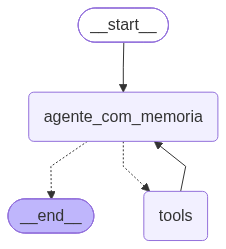

In [5]:
# Define o contrato de comportamento do agente que poderá reutilizar o histórico da mesma thread.
SYSTEM_MEMORY = """
Você é um agente operacional com memória de curto prazo por thread.

REGRAS:
- Use tools para fatos operacionais.
- Considere o histórico da mesma thread em follow-ups.
- Não transforme inferência antiga em fato: revalide quando necessário.
- Consulte políticas para recomendações com custo, SLA ou troca de transportadora.
- Não execute ações externas.
"""

# Disponibiliza as tools ao modelo usado pelo agente com memória.
memory_llm = llm.bind_tools(TOOLS)

# Cria um checkpointer em memória; ele guardará snapshots do estado associados a cada thread_id.
checkpointer = InMemorySaver()

# Define o nó principal do agente com memória.
def memory_agent(state: MessagesState):
    # Chama o modelo usando o prompt de sistema e todo o histórico recuperado para a thread atual.
    response = memory_llm.invoke([SystemMessage(content=SYSTEM_MEMORY), *state["messages"]])

    # Devolve a nova mensagem para ser adicionada ao histórico.
    return {"messages": [response]}

# Define o roteamento entre o agente e o nó de tools.
def memory_route(state: MessagesState):
    # Verifica se a última resposta do modelo contém tool calls.
    has_tool_calls = getattr(state["messages"][-1], "tool_calls", None)

    # Se houver tool call, executa a ferramenta; caso contrário, encerra a rodada.
    return "tools" if has_tool_calls else END

# Cria o grafo usando MessagesState, que mantém uma sequência de mensagens.
builder = StateGraph(MessagesState)

# Registra o nó do agente.
builder.add_node("agente_com_memoria", memory_agent)

# Registra o nó executor de tools.
builder.add_node("tools", ToolNode(TOOLS))

# Define o agente como primeiro passo da execução.
builder.add_edge(START, "agente_com_memoria")

# Depois do agente, decide condicionalmente entre tools e término.
builder.add_conditional_edges(
    "agente_com_memoria",
    memory_route,
    {"tools": "tools", END: END},
)

# Depois da tool, volta ao agente com a observação recém-obtida.
builder.add_edge("tools", "agente_com_memoria")

# Compila o grafo e conecta o checkpointer; é isso que habilita continuidade por thread_id.
memory_graph = builder.compile(checkpointer=checkpointer)

# Confirma a compilação.
print("Grafo com Memória compilado:")

# Exibe o desenho do fluxo.
show_graph(memory_graph)

In [6]:
# Define um identificador para a conversa; chamadas com o mesmo valor compartilharão memória.
THREAD_ID = "bootcamp-logistica-01"

# Cria a configuração do LangGraph com o thread_id e também um limite de recursão/ciclos.
config = {
    "configurable": {"thread_id": THREAD_ID},
    "recursion_limit": 20,
}

# Exemplo do primeiro input: "Investigue o HUB-BH e identifique sinais anormais."

# Solicita ao usuário o primeiro prompt da conversa.
prompt_1 = "Qual gargalo mais ameaça o SLA ? cruze operação, incidentes, atendimento, custo e políticas."

# Executa o grafo usando a configuração que contém o THREAD_ID.
result_1 = memory_graph.invoke(
    {"messages": [HumanMessage(content=prompt_1)]},
    config=config,
)

# Exibe a primeira resposta do agente.
show_final_message(result_1)

# Exemplo do follow-up: "Agora compare isso com o atendimento e revise a recomendação."

# Solicita uma segunda pergunta sem exigir que o usuário repita todo o contexto anterior.
prompt_2 = "Qual ação deveria ser tomada nas próximas 48 horas levando em conta a ameaça ao SLA ? Cruze operação, incidentes, atendimento, custo e políticas."

# Executa novamente o MESMO grafo e o MESMO thread_id; o checkpointer recupera o histórico salvo.
result_2 = memory_graph.invoke(
    {"messages": [HumanMessage(content=prompt_2)]},
    config=config,
)

# Exibe a resposta ao follow-up, agora contextualizada pelo histórico da thread.
show_final_message(result_2)

### Resposta
O gargalo que mais ameaça o SLA atualmente é a **saturação operacional do HUB-BH**, que apresenta um efeito cascata em todas as dimensões analisadas.

Abaixo, apresento o cruzamento detalhado dos dados:

### 1. Operação e Políticas (Risco Crítico)
O **HUB-BH** é o ponto de maior vulnerabilidade. Ele opera com **105,32% de utilização média** e um backlog de **286,2 volumes** (pico de 420). 
*   **Violação de Política:** De acordo com a **Política 5**, qualquer hub acima de 100% de utilização e 150 volumes de backlog é considerado **Risco Operacional Alto**. O HUB-BH excede o limite de backlog em quase 100%.
*   **Fator Humano:** O absenteísmo no HUB-BH é o mais alto da rede (**12,26%**), o que impede a vazão do backlog acumulado.

### 2. Incidentes (Impacto Sistêmico)
O HUB-BH concentra os incidentes mais severos, o que agrava a saturação:
*   **Severidade Crítica:** Registrou "Chuva Severa" com impacto total de 335.
*   **Falhas Internas:** "Falha de esteira" (impacto 313) e "Indisponibilidade de sistema" (impacto 301) sugerem que a infraestrutura física e lógica do hub está sob estresse extremo.

### 3. Atendimento (Reflexo no Cliente)
O gargalo operacional reflete diretamente no suporte:
*   O tópico **"Avaria"** lidera em volume (77 tickets) e tem o pior desempenho de SLA, com **48,05% dos chamados fora do prazo**.
*   Isso está diretamente correlacionado aos incidentes de "Falha de esteira" e "Avaria em veículo" concentrados no HUB-BH e rotas adjacentes.

### 4. Custo e Performance de Rotas
A rota **R-SP-PR** é a mais crítica em termos de entrega, com apenas **25,5% de On-Time** e o maior atraso médio (9,43h). 
*   **Eficiência Financeira:** Esta rota possui a menor margem da operação (**32,86%**). Estamos operando com custo elevado para um nível de serviço inaceitável.
*   **Transportadoras:** Diversas transportadoras (como Nexo Log e RotaSul em certas rotas) operam abaixo de **80% de pontualidade**, o que, pela **Política 6**, deveria restringir o recebimento de novos volumes.

---

**Conclusão:** O "nó" da rede é o **HUB-BH**. Enquanto a utilização não for reduzida para níveis abaixo de 100% e o backlog não for drenado, o SLA das rotas conectadas continuará em queda, gerando custos de reentrega e sobrecarga no atendimento por avarias.

**Gostaria que eu simulasse um cenário de reencaminhamento de volumes do HUB-BH para outros hubs (como HUB-RJ ou HUB-GO) para aliviar a pressão e calcular o impacto no custo?**

### Resposta
Com base no cruzamento de dados e nas restrições das políticas vigentes, a ação prioritária para as próximas 48 horas deve ser o **desvio imediato de carga do HUB-BH para o HUB-RJ**, focando na redução do backlog crítico.

Abaixo, detalho a recomendação estruturada:

### 1. Fatos Observados
*   **Operação:** O HUB-BH opera com **105,32% de utilização** e backlog de **286 volumes**, violando a **Política 5** (Risco Alto).
*   **Incidentes:** O hub sofreu falhas de infraestrutura (esteira e sistema) e clima, acumulando um impacto de mais de **900 pontos de severidade**.
*   **Atendimento:** O volume de tickets por **Avaria** (77) e **Atraso** (67) está saturando o suporte, com quase 50% dos casos fora do SLA.
*   **Custo:** A rota R-SP-PR apresenta a pior margem (32,86%) e o maior atraso, indicando ineficiência no fluxo atual.

### 2. Ação Proposta: Contingência de Fluxo
Recomendo o **redirecionamento de 150 volumes** (aproximadamente 50% do backlog atual) do **HUB-BH para o HUB-RJ**.

*   **Viabilidade Financeira:** O custo incremental estimado é de **R$ 1.179,00** (12% de acréscimo por remessa).
*   **Conformidade com Políticas:** Esta ação **não exige aprovação humana imediata** segundo a **Política 2**, pois o aumento de custo (12%) é inferior ao limite de 15%.
*   **Impacto no SLA:** Previsão de redução de **12 horas no atraso médio** das cargas afetadas, aliviando a pressão sobre o HUB-BH para que a equipe local (com alto absenteísmo) consiga processar o restante.

### 3. Ações Complementares (Próximas 48h)
*   **Comunicação Proativa:** Conforme a **Política 4**, disparar alertas para todos os clientes **Enterprise** com cargas passando pelo HUB-BH, dado que o atraso médio p95 na região ultrapassa 30 horas.
*   **Bloqueio de Volume:** Aplicar a **Política 6** para a transportadora **Nexo Log** na rota R-SP-PR (On-time de 79%), impedindo novos incrementos de carga até a normalização dos indicadores.

---

**Resumo do Risco:**
A alternativa de desvio para o HUB-GO foi descartada como ação imediata pois o custo incremental (18%) exigiria aprovação humana (Política 2), o que atrasaria a execução dentro da janela de 48 horas.

**Deseja que eu gere o relatório formal de contingência para o HUB-RJ ou prefere que eu investigue a causa raiz do absenteísmo no HUB-BH?**

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">9. Comparação e desafio final</h1>

| Arquitetura | Vantagem | Falha dominante a observar |
|---|---|---|
| ReAct | investigação adaptativa | loops e uso excessivo de tools |
| Planejamento | etapas auditáveis | plano rígido ou overplanning |
| Memória | continuidade | perpetuar contexto incorreto |
| Multiagente | especialização e permissões | custo/conflito entre especialistas |
| Reflexão | quality gate | autojustificação e latência |

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">Desafio</h2>

Use **a mesma missão nas cinco arquiteturas**:

`Qual gargalo mais ameaça o SLA e qual ação deveria ser tomada nas próximas 48 horas? Cruze operação, incidentes, atendimento, custo e políticas.`

Compare quantidade de tools, qualidade da evidência, previsibilidade, custo/latência, visibilidade das falhas e necessidade de aprovação humana.

Qual gargalo mais ameaça o SLA ? cruze operação, incidentes, atendimento, custo e políticas.
Qual ação deveria ser tomada nas próximas 48 horas ? Cruze operação, incidentes, atendimento, custo e políticas.